This notebook is meant to be run AFTER all of the filled-out `labels.csv` files are added to the necessary label_sesion directory. Running this notebook will combine the new labels with all of the old labels and data

In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import ast # turns str(list(int)) to list(int)
import matplotlib.pyplot as plt
import json

In [2]:
session_dir = Path('/data/vision/polina/users/marcusbl/bin_class/label_sessions_data/label_session_3-11')

old_data = pd.read_csv(session_dir / 'labeled_slice_df.csv', index_col = 0)

# Create DataFrame for NEW labels

This dataframe will have following columns:
- `path`: path to the stack 
- `slice_num`: which slice in the stack we are referring to
- `labels`: list of all labels [0 = good, 1 = bad, 2 = questionable]
- `is_edge`: list of boolean Flag whether this is an edge slice or not

In [3]:
# lookup: (pdf_num, stack_num) -> stack
with open(session_dir / 'lookup.json', 'r') as f:
    stack_lookup = json.load(f)

In [4]:
def get_label(slice_num: int, bad_slices: set[int], quest_slices: set[int]):
    """
    Returns the label for a given slice, given the bad & questionable slices in the stack

    GOOD = 0; BAD = 1; QUESTIONABLE = 2
    """
    if slice_num in bad_slices:
        return 1
    elif slice_num in quest_slices:
        return 2
    else:
        return 0

In [5]:
results = []

for group_dir in session_dir.iterdir():

    # skip the files in the session_dir
    if not group_dir.is_dir() or 'group' not in group_dir.stem: 
        continue 

    pdf_num = int(group_dir.stem.split('group')[-1])
    all_stack_info = pd.read_csv(group_dir / f'labels_{pdf_num}.csv', index_col = 0) 

    # Loop through all stacks in this pdf
    for stack_num in all_stack_info.columns:
        stack_info = all_stack_info[stack_num]

        skip_column = stack_info.iloc[0] is np.nan

        if skip_column:
            print(f"No start/end info found for {pdf_num}-{stack_num}. Skipping...")
            continue

        # Get start and end for non-edges
        start = int(stack_info.iloc[0])
        end = int(stack_info.iloc[1])

        # Get stack path & which slices are valid
        lookup_key = f"{pdf_num}-{stack_num}"
        if lookup_key not in stack_lookup:
            print('here')
            continue
        
        stack_path = stack_lookup[lookup_key]
        valid_slices_str = old_data.loc[old_data['path'] == str(stack_path), 'stack_slices'].iloc[0]
        valid_slices = ast.literal_eval(valid_slices_str) # str -> int

        # Get labels for the stack
        stack_label_info = stack_info.iloc[3:] # skip first 3 rows
        is_quest = stack_label_info.astype(str).str.contains('\?')
        bad_slices = set(int(num) for num in stack_label_info[~is_quest] if pd.notna(num) )
        quest_slices = set(int(num[:-1]) for num in stack_label_info[is_quest] if pd.notna(num))
            
        #Add each slice to results
        for slice_num in valid_slices:
            results.append({
                'path': stack_path, 
                'slice_num': slice_num, 
                'label': get_label(slice_num, bad_slices, quest_slices),
                'is_edge': (slice_num < start) or (slice_num > end),
                'pdf_num': pdf_num
            })

No start/end info found for 11-24. Skipping...
No start/end info found for 11-25. Skipping...
No start/end info found for 11-26. Skipping...
No start/end info found for 11-27. Skipping...
No start/end info found for 11-28. Skipping...
No start/end info found for 11-29. Skipping...
No start/end info found for 11-30. Skipping...
No start/end info found for 11-31. Skipping...
No start/end info found for 11-32. Skipping...
No start/end info found for 11-33. Skipping...
No start/end info found for 11-34. Skipping...
No start/end info found for 11-35. Skipping...
No start/end info found for 11-36. Skipping...
No start/end info found for 11-37. Skipping...
No start/end info found for 11-38. Skipping...
No start/end info found for 11-39. Skipping...
No start/end info found for 11-40. Skipping...
No start/end info found for 11-41. Skipping...
No start/end info found for 11-42. Skipping...
No start/end info found for 11-43. Skipping...
No start/end info found for 11-44. Skipping...
No start/end 

Now, take the results dataframe and join based on repeated stack labels:
1. Labels are concatenated into a list entry
2. is_edge is True if is_edge true for any of the labels

In [6]:
results_df = pd.DataFrame(results)

In [7]:
print(len(set(results_df['path'])))

287


In [8]:
results_df

,path,slice_num,label,is_edge,pdf_num
0,/data/vision/polina/users/mfirenze/Data_sharin...,0,0,True,1
1,/data/vision/polina/users/mfirenze/Data_sharin...,1,0,True,1
2,/data/vision/polina/users/mfirenze/Data_sharin...,2,0,False,1
3,/data/vision/polina/users/mfirenze/Data_sharin...,3,0,False,1
4,/data/vision/polina/users/mfirenze/Data_sharin...,4,1,False,1
...,...,...,...,...,...
16787,/data/vision/polina/users/mfirenze/Data_sharin...,27,0,False,9
16788,/data/vision/polina/users/mfirenze/Data_sharin...,28,0,False,9
16789,/data/vision/polina/users/mfirenze/Data_sharin...,29,0,False,9
16790,/data/vision/polina/users/mfirenze/Data_sharin...,30,0,True,9


In [11]:
merged_df = (
    results_df
    .groupby(["path", "slice_num"], as_index=False)
    .agg({
        "label": list,
        "is_edge": "any",
    })
)
merged_df['num_labels'] = merged_df['label'].apply(len)

def labels_agree(x: list[int]):
    if len(x) == 1:
        raise ValueError("1 element instead of 2?!")
    return x[0] == x[1]
merged_df = merged_df.rename(columns={'label': 'label_2'})

In [12]:
merged_df

,path,slice_num,label_2,is_edge,num_labels
0,/data/vision/polina/users/marcusbl/data/anon-0...,4,"[1, 0]",False,2
1,/data/vision/polina/users/marcusbl/data/anon-0...,5,"[1, 1]",False,2
2,/data/vision/polina/users/marcusbl/data/anon-0...,6,"[1, 1]",False,2
3,/data/vision/polina/users/marcusbl/data/anon-0...,7,"[1, 1]",False,2
4,/data/vision/polina/users/marcusbl/data/anon-0...,8,"[1, 1]",False,2
...,...,...,...,...,...
8391,/data/vision/polina/users/mfirenze/Data_sharin...,27,"[0, 0]",False,2
8392,/data/vision/polina/users/mfirenze/Data_sharin...,28,"[0, 0]",False,2
8393,/data/vision/polina/users/mfirenze/Data_sharin...,29,"[0, 0]",False,2
8394,/data/vision/polina/users/mfirenze/Data_sharin...,30,"[0, 0]",True,2


# Final Merge

Here, we merge the data acquired during this data labeling session w/ all of our past data. 
We merge `all_slices_df` which has all of the possible slices w/ labels if they exist, with the new `merged_df`

In [13]:
all_slices_df = pd.read_csv('/data/vision/polina/users/marcusbl/bin_class/label_sessions_data/label_session_3-11/labeled_slice_df.csv', index_col = 0)
all_slices_df.head(2)

,slice_num,stack_slices_cnt,full_stack_slices_cnt,stack_slices,path,Brain Type,person,dataset,mask_path,MAP ID,GA,person_id,label_R,label_1
0,3,34,42,"[3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, ...",/data/vision/polina/users/marcusbl/data/anon-0...,NaN,anon-00067-2-11-2015,R,/data/vision/polina/users/marcusbl/data/anon-0...,NaN,NaN,0,0.0,"[1, 0]"
1,4,34,42,"[3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, ...",/data/vision/polina/users/marcusbl/data/anon-0...,NaN,anon-00067-2-11-2015,R,/data/vision/polina/users/marcusbl/data/anon-0...,NaN,NaN,0,0.0,"[1, 1]"


In [14]:
final_df = merged_df = all_slices_df.merge(
    merged_df[['path', 'slice_num', 'is_edge', 'label_2']], 
    on=['path', 'slice_num'], 
    how='outer'
)
final_df['is_edge'] = final_df['is_edge'].astype('Int64')

In [15]:
print(len(final_df))
final_df.head()

20212


,slice_num,stack_slices_cnt,full_stack_slices_cnt,stack_slices,path,Brain Type,person,dataset,mask_path,MAP ID,GA,person_id,label_R,label_1,is_edge,label_2
0,1,10,17,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10]",/data/vision/polina/users/marcusbl/data/anon-0...,NaN,anon-00003,R,/data/vision/polina/users/marcusbl/data/anon-0...,NaN,NaN,27,NaN,NaN,<NA>,NaN
1,2,10,17,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10]",/data/vision/polina/users/marcusbl/data/anon-0...,NaN,anon-00003,R,/data/vision/polina/users/marcusbl/data/anon-0...,NaN,NaN,27,1.0,NaN,<NA>,NaN
2,3,10,17,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10]",/data/vision/polina/users/marcusbl/data/anon-0...,NaN,anon-00003,R,/data/vision/polina/users/marcusbl/data/anon-0...,NaN,NaN,27,0.0,NaN,<NA>,NaN
3,4,10,17,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10]",/data/vision/polina/users/marcusbl/data/anon-0...,NaN,anon-00003,R,/data/vision/polina/users/marcusbl/data/anon-0...,NaN,NaN,27,1.0,NaN,<NA>,NaN
4,5,10,17,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10]",/data/vision/polina/users/marcusbl/data/anon-0...,NaN,anon-00003,R,/data/vision/polina/users/marcusbl/data/anon-0...,NaN,NaN,27,0.0,NaN,<NA>,NaN


# Analyzing the Final Labels

Checking how many slices require relabeling

In [18]:
def labels_agree(x, ):
    # catch NaNs (floats)
    if isinstance(x, float):
        return False
        
    if not x:
        return False
        
    if len(x) == 1:
        return False
        
    return x[0] == x[1]

final_df['labels_agree'] = final_df['label_2'].apply(labels_agree)
final_df['req_relabel'] = final_df['label_2'].notna() & ~final_df['is_edge'] & ~final_df['labels_agree']

In [19]:
final_df['req_relabel'].sum()

np.int64(1184)

Check how many of these cases will be tie-broken by Label_1

In [20]:
def can_break_tie(row):
    l1 = row['label_1']
    l2 = row['label_2']
    lR = row['label_R']
    
    # Check if l2 is a valid list/collection with at least 2 items
    if not isinstance(l2, (list, tuple)) or len(l2) < 2:
        return False
    
    # If the labels in l2 already agree, there is no tie to break
    if l2[0] == l2[1]:
        return False
        
    # Check if the value in label_1 exists within the label_2 collection
    # This "breaks the tie" by confirming one of the disputed options
    if isinstance(l1, str): 
        l1_list = ast.literal_eval(l1)
        if len(l1_list) == 1:
            return True # tie has been broken by 3rd!
        else:
            if l1_list[0] == l1_list[1]: # if they are the same, tie still broken
                return True
    
    # Otherwise, break the tie w/ the original label
    if not np.isnan(lR):
        return True 

final_df['tie_broken'] = final_df.apply(can_break_tie, axis=1)

In [21]:
final_df['tie_broken'].sum()

923

In [22]:
final_df.to_csv('/data/vision/polina/users/marcusbl/bin_class/label_sessions_data/label_session_3-11/post_session.csv')

Displaying cases when labels disagree

In [23]:
from generate_mosaics import display_slice
import nibabel as nib

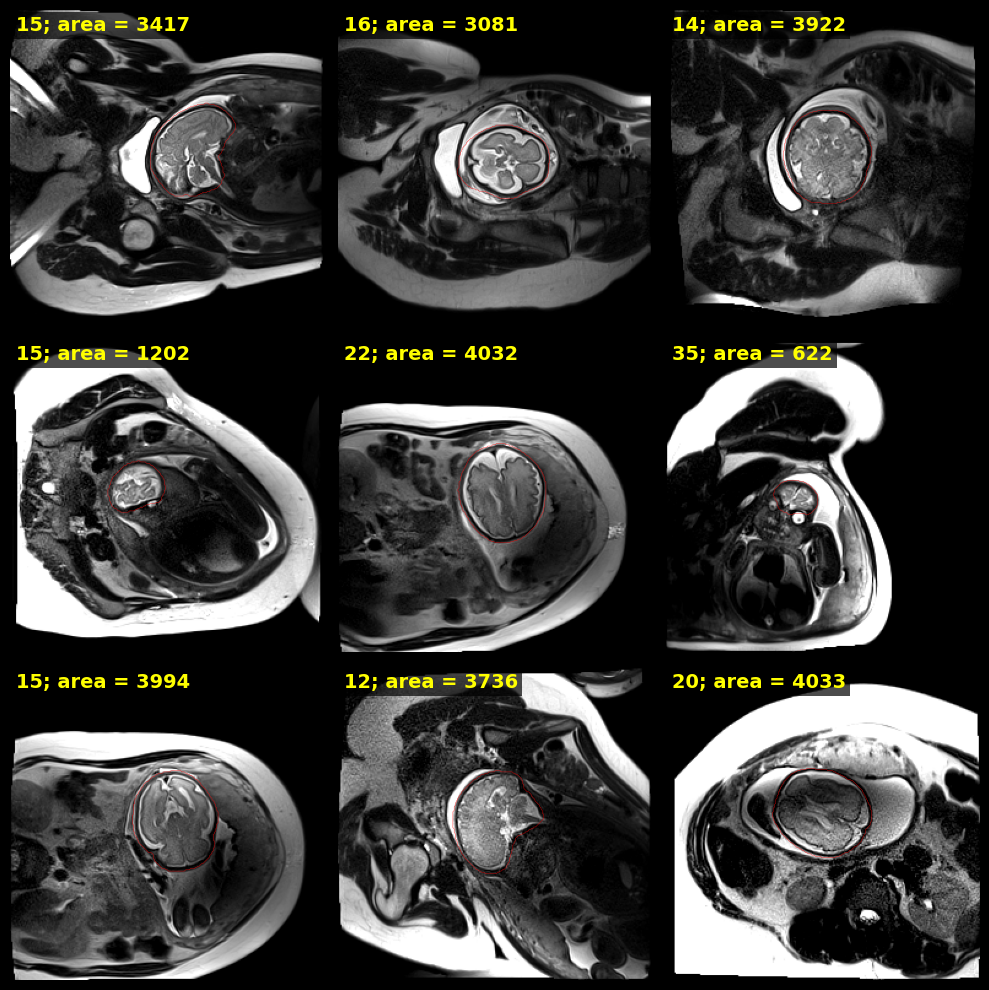

In [24]:
fig, axes = plt.subplots(3, 3, figsize=(10, 10))
axes = axes.flatten()  # makes indexing easier

filtered_df = final_df[final_df['req_relabel']].sample(frac=1).reset_index(drop=True)

for i, (_, row) in enumerate(filtered_df.iterrows()):
    if i >= 9:
        break  # only fill 3x3 grid

    stack_path = Path(row['path'])
    mask_path = Path(row['mask_path'])
    slice_num = row['slice_num']

    # Load nifti data
    if stack_path.suffix == '.npy':
        nifti_data = np.load(stack_path)
    else:
        nifti_img = nib.load(stack_path)
        nifti_data = nifti_img.get_fdata()

    # Load mask data
    if mask_path.suffix == '.npy':
        mask_data = np.load(mask_path).astype(bool)
    else:
        mask_img = nib.load(mask_path)
        mask_data = mask_img.get_fdata().astype(bool)

    display_slice(nifti_data, mask_data, slice_num, axes[i])

plt.tight_layout()
plt.show()